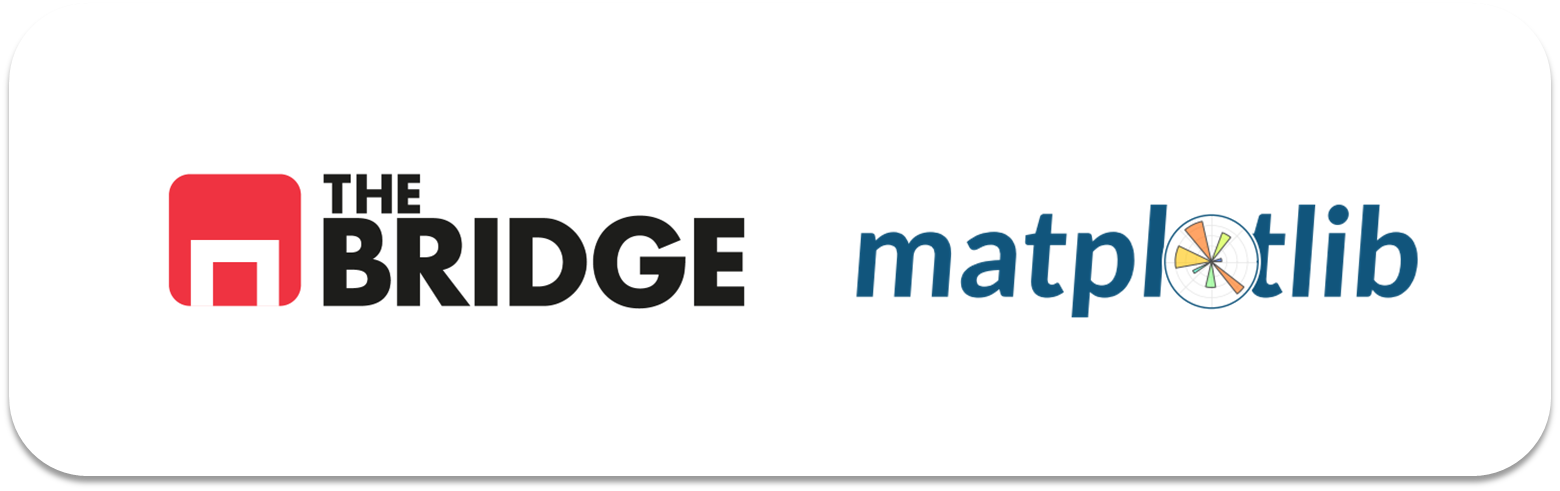

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [2]:
import matplotlib.pyplot as plt   # Librería principal de gráficos
import numpy as np                # Para generar datos numéricos
import pandas as pd               # Para cargar datasets si los necesitas
import seaborn as sns             # Para estilos y gráficos estadísticos

# Ajustes opcionales de estilo
sns.set(style="whitegrid")        # Estilo visual agradable
plt.rcParams["figure.figsize"] = (8, 5)   # Tamaño por defecto de las figuras

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [3]:
# Cargamos el CSV
df_california = pd.read_csv("./data/california_cities.csv")

# Mostramos una parte del contenido
df_california.head()

# Mostramos información general del dataset
df_california.info()

# Eliminamos filas con valores nulos
df_california = df_california.dropna()

# Comprobamos que ya no quedan nulos
df_california.info()

<class 'pandas.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    str    
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 52.8 KB
<class 'pandas.DataFrame'>
Index: 427 entries, 0 to 481
Data c

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

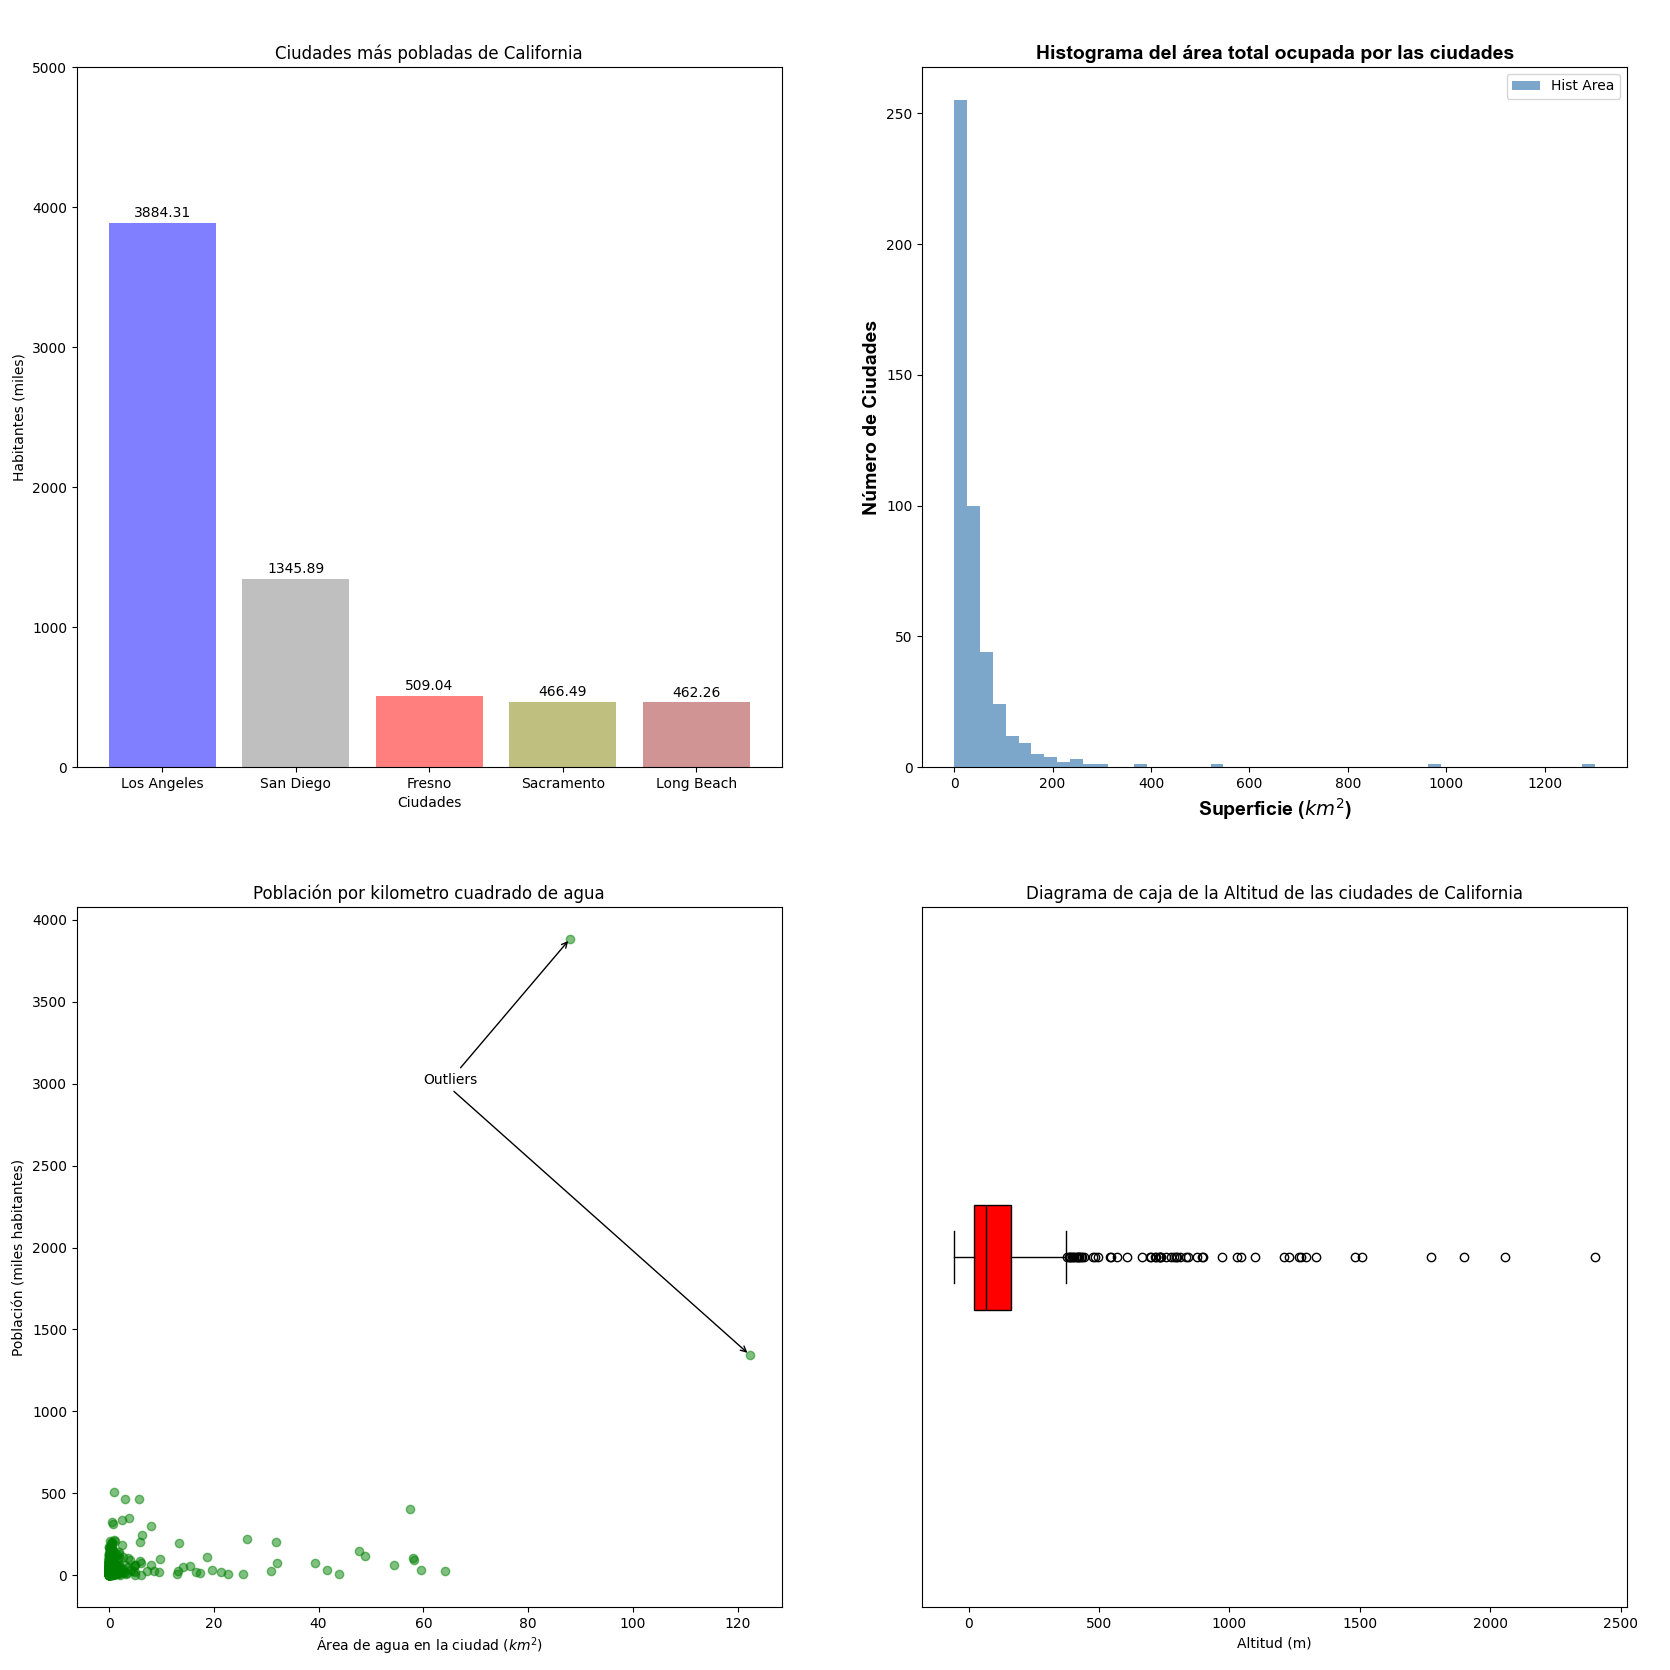

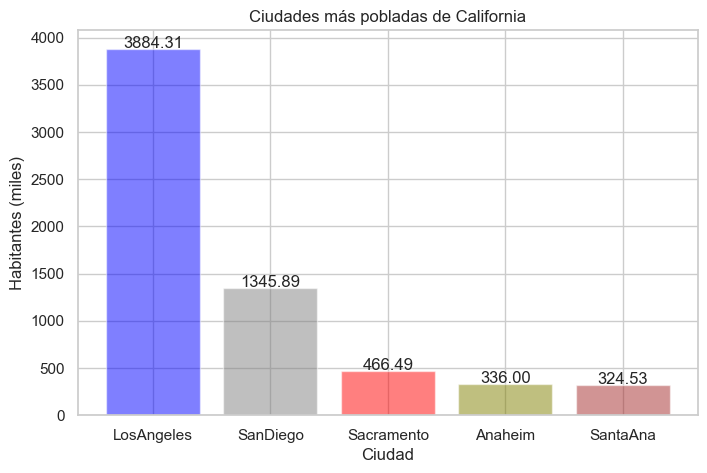

In [6]:
# Seleccionamos las 5 ciudades más pobladas
top5 = df_california.nlargest(5, "population_total")

# Colores con 50% de transparencia
colores = ["blue", "gray", "red", "olive", "brown"]

plt.figure(figsize=(8,5))
plt.bar(top5["city"], top5["population_total"]/1000, color=colores, alpha=0.5)  # Barras

# Etiquetas centradas sobre cada barra
for i, valor in enumerate(top5["population_total"]/1000):
    plt.text(i, valor + 10, f"{valor:.2f}", ha="center")  # Texto centrado

plt.title("Ciudades más pobladas de California")
plt.ylabel("Habitantes (miles)")
plt.xlabel("Ciudad")
plt.show()

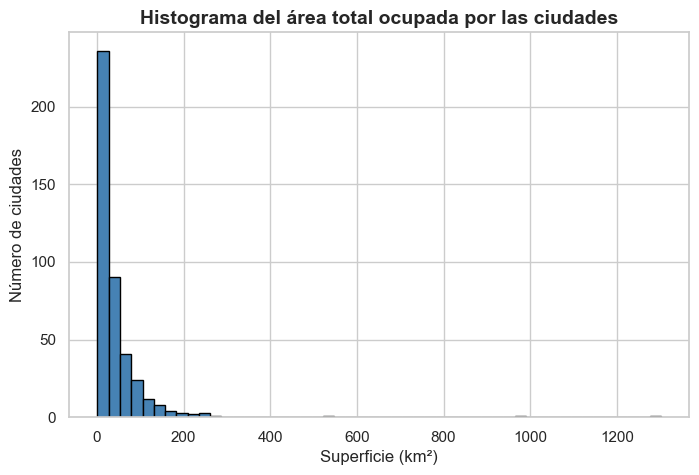

In [7]:
# Histograma del área total de las ciudades
plt.figure(figsize=(8,5))
plt.hist(df_california["area_total_km2"], bins=50, color="steelblue", edgecolor="black")

plt.title("Histograma del área total ocupada por las ciudades",
          fontname="Arial", fontsize=14, fontweight="bold")
plt.xlabel("Superficie (km²)")
plt.ylabel("Número de ciudades")
plt.show()

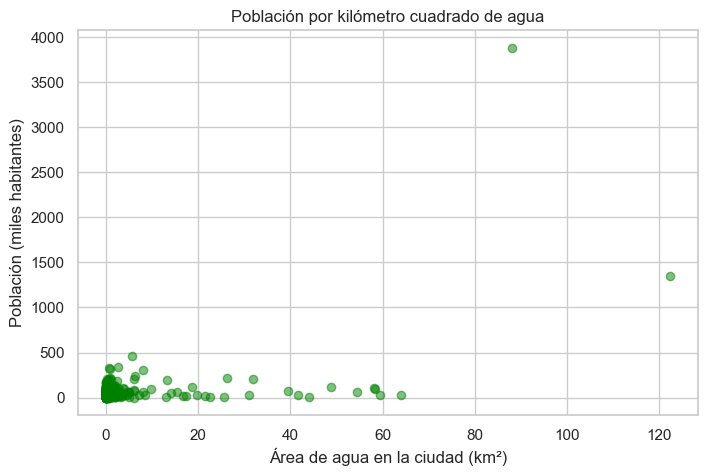

In [8]:
# Scatter de área de agua vs población
plt.figure(figsize=(8,5))
plt.scatter(df_california["area_water_km2"],
            df_california["population_total"]/1000,
            alpha=0.5, color="green")  # Transparencia y color

plt.title("Población por kilómetro cuadrado de agua")
plt.xlabel("Área de agua en la ciudad (km²)")
plt.ylabel("Población (miles habitantes)")
plt.show()

In [13]:
# Boxplot de la altitud de las ciudades
# plt.figure(figsize=(6,4))
# plt.boxplot(df_california["elevation_m"],
            # patch_artist=True,
            # boxprops={"facecolor": "red"})  # Color del boxplot
#
# plt.title("Diagrama de caja de la Altitud de las ciudades de California")
# plt.xlabel("Altitud (m)")
# plt.show()

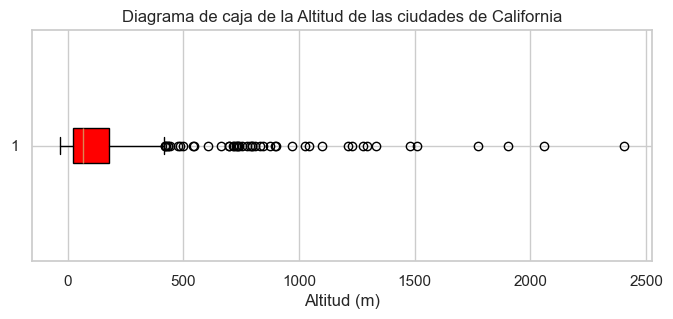

In [12]:
# Boxplot de la altitud en formato horizontal

plt.figure(figsize=(8,3))
plt.boxplot(df_california["elevation_m"],
            vert=False,                 # <-- Esto lo hace horizontal
            patch_artist=True,
            boxprops={"facecolor": "red"})  # Color del boxplot

plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.xlabel("Altitud (m)")
plt.show()

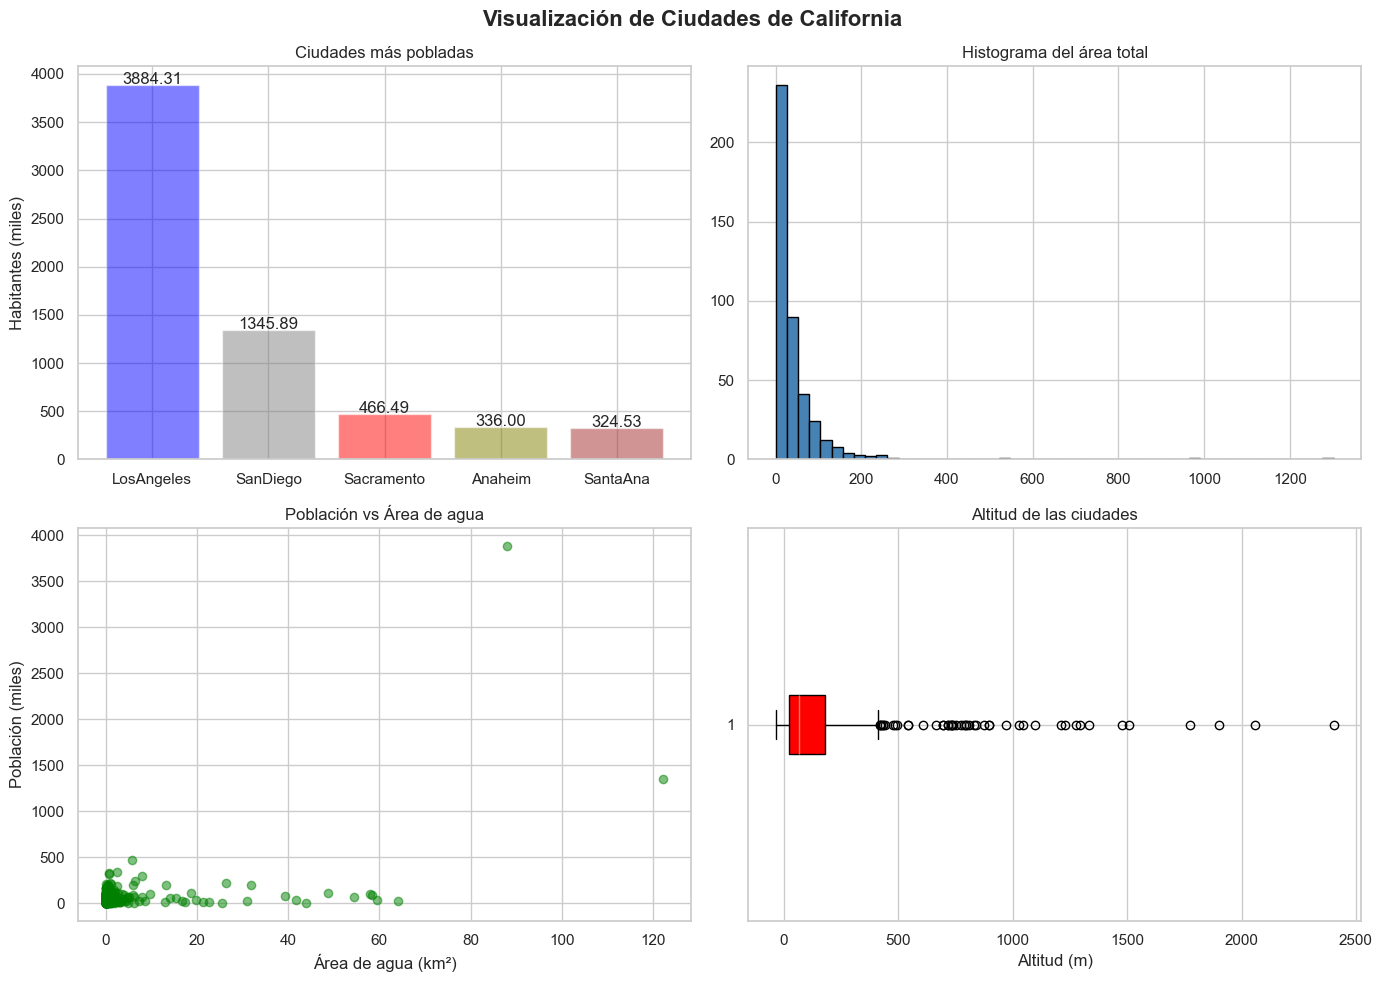

In [15]:
# Figura con los 4 gráficos juntos
fig, axs = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Visualización de Ciudades de California", fontsize=16, fontweight="bold")

# --- Gráfico 1: Ciudades más pobladas ---
axs[0,0].bar(top5["city"], top5["population_total"]/1000,
             color=colores, alpha=0.5)  # Barras con transparencia

# Etiquetas centradas
for i, valor in enumerate(top5["population_total"]/1000):
    axs[0,0].text(i, valor + 10, f"{valor:.2f}", ha="center")

axs[0,0].set_title("Ciudades más pobladas")
axs[0,0].set_ylabel("Habitantes (miles)")

# --- Gráfico 2: Histograma del área total ---
axs[0,1].hist(df_california["area_total_km2"], bins=50,
              color="steelblue", edgecolor="black")
axs[0,1].set_title("Histograma del área total")

# --- Gráfico 3: Scatter área de agua vs población ---
axs[1,0].scatter(df_california["area_water_km2"],
                 df_california["population_total"]/1000,
                 alpha=0.5, color="green")
axs[1,0].set_title("Población vs Área de agua")
axs[1,0].set_xlabel("Área de agua (km²)")
axs[1,0].set_ylabel("Población (miles)")

# --- Gráfico 4: Boxplot horizontal de altitud ---
axs[1,1].boxplot(df_california["elevation_m"],
                 vert=False,                      # <-- Horizontal
                 patch_artist=True,
                 boxprops={"facecolor": "red"})   # Color del boxplot

axs[1,1].set_title("Altitud de las ciudades")
axs[1,1].set_xlabel("Altitud (m)")

plt.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

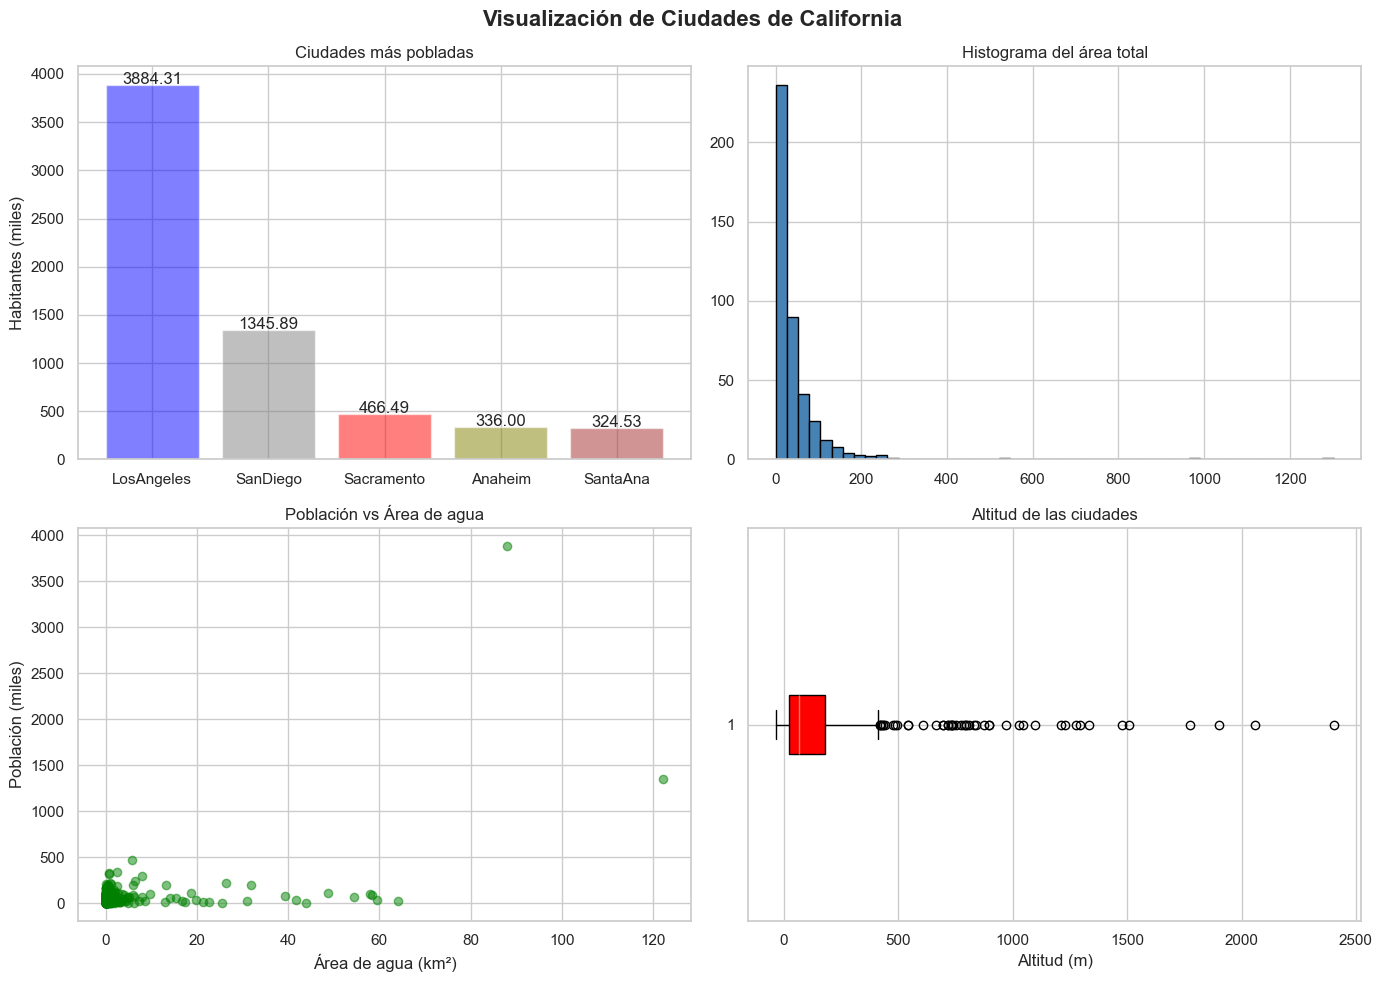

In [17]:
# Figura con los 4 gráficos juntos
fig, axs = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle("Visualización de Ciudades de California", fontsize=16, fontweight="bold")

# --- Gráfico 1 ---
axs[0,0].bar(top5["city"], top5["population_total"]/1000, color=colores, alpha=0.5)
for i, valor in enumerate(top5["population_total"]/1000):
    axs[0,0].text(i, valor + 10, f"{valor:.2f}", ha="center")
axs[0,0].set_title("Ciudades más pobladas")
axs[0,0].set_ylabel("Habitantes (miles)")

# --- Gráfico 2 ---
axs[0,1].hist(df_california["area_total_km2"], bins=50, color="steelblue", edgecolor="black")
axs[0,1].set_title("Histograma del área total")

# --- Gráfico 3 ---
axs[1,0].scatter(df_california["area_water_km2"],
                 df_california["population_total"]/1000,
                 alpha=0.5, color="green")
axs[1,0].set_title("Población vs Área de agua")
axs[1,0].set_xlabel("Área de agua (km²)")
axs[1,0].set_ylabel("Población (miles)")

# --- Gráfico 4 (horizontal) ---
axs[1,1].boxplot(df_california["elevation_m"],
                 vert=False,
                 patch_artist=True,
                 boxprops={"facecolor": "red"})
axs[1,1].set_title("Altitud de las ciudades")
axs[1,1].set_xlabel("Altitud (m)")

plt.tight_layout()

# --- Guardar la figura en un archivo PNG ---
plt.savefig("figura_california.png", dpi=300)   # <-- Aquí se guarda el archivo

plt.show()